In [1]:
print('k')

k


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Importing required modules
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from diffusers import UNet2DModel , DDPMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
# Took help of LLM to find pretrained models and load the weights according to our dataset
model_id = "google/ddpm-cifar10-32"
unet = UNet2DModel.from_pretrained(model_id)
scheduler = DDPMScheduler.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [6]:
# Importing a pretrained classifier to predict the labels of images generated
from torchvision.models import resnet50
classifier=resnet50(pretrained=True)
classifier.fc=nn.Linear(2048,10)
classifier=classifier.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# Loading the dataset
save_dir="/content/drive/MyDrive/cifer_10_data/"
train_images = np.load(os.path.join(save_dir, 'train_images.npy'))
train_labels = np.load(os.path.join(save_dir, 'train_labels.npy'))
test_images = np.load(os.path.join(save_dir, 'test_images.npy'))
test_labels = np.load(os.path.join(save_dir, 'test_labels.npy'))

In [8]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


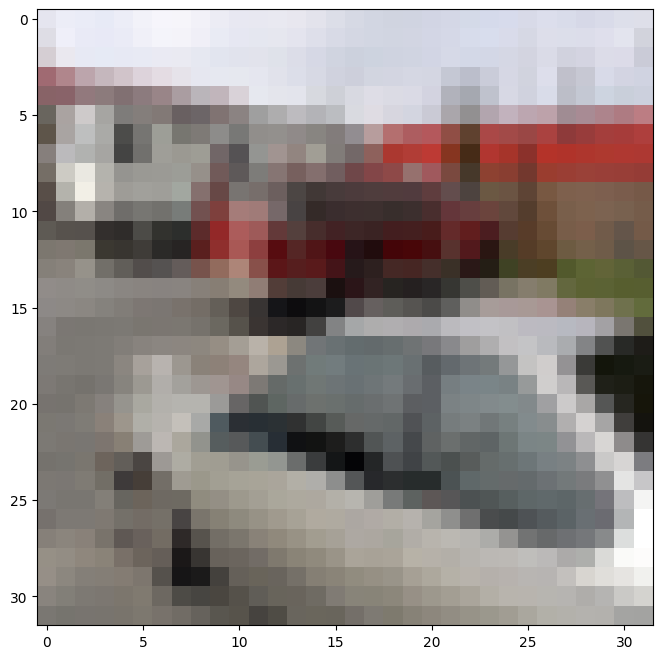

In [9]:
# Visualizing how the images look like
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.imshow(train_images[-1])
plt.show()

In [10]:
print(train_labels[-1])

[1]


In [11]:
# Forming batches , took less number of images to reduce computation
from torch.utils.data import TensorDataset , DataLoader
train_images_tensor=torch.tensor(train_images[:1024]).float()
train_labels_tensor=torch.tensor(train_labels[:1024])
test_images_tensor=torch.tensor(test_images[:256]).float()
test_labels_tensor=torch.tensor(test_labels[:256])

training_dataset=TensorDataset(train_images_tensor,train_labels_tensor)
testing_dataset=TensorDataset(test_images_tensor,test_labels_tensor)

train_loader=DataLoader(training_dataset,batch_size=8)
test_loader=DataLoader(testing_dataset,batch_size=8)

In [20]:
# Passing only weights of last layer since it's the only one not pretrained
criterion=nn.CrossEntropyLoss()
for param in classifier.parameters():
    param.requires_grad = False
classifier.fc.requires_grad_(True)
optimizer=torch.optim.Adam(classifier.fc.parameters(),lr=1e-3)

In [22]:
# Setting a transformer to make images of shape required for resnet50 and normalizing it
from torchvision import transforms
transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [26]:
## Training loop
classifier.train()
unet.to(device)
unet.eval()
scheduler.set_timesteps(50) # Setting the timesteps according to computation power(First I was getting a OOM error due to this took help of LLM to come to this conclusion)
for epoch in range(15):
  total_loss=0
  for X_batch , y_batch in train_loader:
    optimizer.zero_grad()
    X_batch=X_batch.permute(0,3,1,2)

    # Normalizing the values for better calculations (First I was getting a OOM error due to this took help of LLM to come to this conclusion)
    X_batch_norm=(X_batch/127.5) - 1.0

    X_batch=X_batch_norm.to(device)
    y_batch=y_batch.to(device)

    y_batch = y_batch.squeeze(1)

    noise=torch.randn_like(X_batch)

    # Partially noising the image so that we can predict labels properly not fully corrupting the image
    time_stamps=torch.tensor([200 for _ in range(X_batch.shape[0])], device=device)
    noisy_images=scheduler.add_noise(X_batch,noise,time_stamps)
    with torch.no_grad():
      for t in scheduler.timesteps:
        if t>200 :
          continue
        time=torch.tensor([t]*X_batch.shape[0],device=device)
        predicting_noise=unet(noisy_images,time)
        denoised=scheduler.step(predicting_noise.sample,t,noisy_images).prev_sample
        noisy_images=denoised
        del predicting_noise,time,denoised

    clear_image=noisy_images.detach()# LLM help to add detach here so it can't take gradients of unet
    clear_image_scaled=((clear_image/2) +0.5 ).clamp(0,1)

    trans_clear_images=[]
    for i in range(clear_image_scaled.shape[0]):
      trans_clear_images.append(transform(clear_image_scaled[i].cpu()))
    trans_clear_image=torch.stack(trans_clear_images).to(device)
    logits=classifier(trans_clear_image)

    loss=criterion(logits,y_batch)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()

    # Explicitly delete additional tensors for memory management
    del X_batch, y_batch, clear_image, clear_image_scaled, trans_clear_image, logits, trans_clear_images, X_batch_norm, noise, time_stamps
    torch.cuda.empty_cache()
  print(f"Epoch {epoch+1} loss : {total_loss}")

Epoch 1 loss : 272.7768428325653
Epoch 2 loss : 270.3073605298996
Epoch 3 loss : 269.30339443683624
Epoch 4 loss : 262.6457322835922
Epoch 5 loss : 262.2895014286041
Epoch 6 loss : 256.46467185020447
Epoch 7 loss : 255.81361377239227
Epoch 8 loss : 255.15540778636932
Epoch 9 loss : 251.4865196943283
Epoch 10 loss : 250.10572791099548
Epoch 11 loss : 250.55906093120575
Epoch 12 loss : 247.86353147029877
Epoch 13 loss : 244.86446285247803
Epoch 14 loss : 244.46308863162994
Epoch 15 loss : 241.776371717453


In [27]:
classifier.eval()
total_id=0
correct_id=0
with torch.no_grad():
  for X_batch , y_batch in test_loader:
    X_batch=X_batch.permute(0,3,1,2)
    X_batch_norm=(X_batch/127.5) - 1.0
    X_batch=X_batch_norm.to(device)
    y_batch=y_batch.to(device)
    y_batch=y_batch.squeeze(1)
    noise=torch.randn_like(X_batch)

    time_stamps=torch.tensor([200]*X_batch.shape[0], device=device)
    noisy_images=scheduler.add_noise(X_batch,noise,time_stamps)

    for t in scheduler.timesteps:
        if t > 200:
          continue
        time=torch.tensor([t]*X_batch.shape[0],device=device)
        predicting_noise=unet(noisy_images,time)
        denoised=scheduler.step(predicting_noise.sample,t,noisy_images).prev_sample
        noisy_images=denoised
        del predicting_noise,time,denoised
    clear_image=noisy_images.detach()
    clear_image_scaled=((clear_image/2) +0.5 ).clamp(0,1)

    trans_clear_images=[]
    for i in range(clear_image_scaled.shape[0]):
      trans_clear_images.append(transform(clear_image_scaled[i].cpu()))
    trans_clear_image=torch.stack(trans_clear_images).to(device)

    logits=classifier(trans_clear_image)
    predictions=torch.argmax(logits,dim=1)
    correct_id+=(predictions==y_batch).sum().item()
    total_id+=y_batch.shape[0]
  print(f"Accuracy : {correct_id*100/total_id}")

Accuracy : 28.125


In [28]:
print(predictions)
print(y_batch)

tensor([4, 1, 3, 6, 1, 1, 4, 0], device='cuda:0')
tensor([2, 2, 5, 3, 9, 9, 4, 0], device='cuda:0', dtype=torch.uint8)


In [24]:
print(scheduler.timesteps)

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])


In [29]:
## Using other scheduler as part of experiment
from diffusers import DDIMScheduler
scheduler1=DDIMScheduler.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [30]:
# Re initializing the classifier for new scheduler
classifier1=resnet50(pretrained=True)
classifier1.fc=nn.Linear(2048,10)
classifier1=classifier1.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
for param in classifier1.parameters():
    param.requires_grad = False
classifier1.fc.requires_grad_(True)
optimizer1=torch.optim.Adam(classifier1.fc.parameters(),lr=1e-3)

In [32]:
## Training loop for new scheduler
classifier1.train()
unet.to(device)
unet.eval()
scheduler1.set_timesteps(50)
for epoch in range(15):
  total_loss=0
  for X_batch , y_batch in train_loader:
    optimizer1.zero_grad()
    X_batch=X_batch.permute(0,3,1,2)

    X_batch_norm=(X_batch/127.5) - 1.0

    X_batch=X_batch_norm.to(device)
    y_batch=y_batch.to(device)

    y_batch = y_batch.squeeze(1)

    noise=torch.randn_like(X_batch)

    time_stamps=torch.tensor([200 for _ in range(X_batch.shape[0])], device=device)
    noisy_images=scheduler1.add_noise(X_batch,noise,time_stamps)
    with torch.no_grad():
      for t in scheduler1.timesteps:
        if t>200 :
          continue
        time=torch.tensor([t]*X_batch.shape[0],device=device)
        predicting_noise=unet(noisy_images,time)
        denoised=scheduler1.step(predicting_noise.sample,t,noisy_images).prev_sample
        noisy_images=denoised
        del predicting_noise,time,denoised

    clear_image=noisy_images.detach()
    clear_image_scaled=((clear_image/2) +0.5 ).clamp(0,1)

    trans_clear_images=[]
    for i in range(clear_image_scaled.shape[0]):
      trans_clear_images.append(transform(clear_image_scaled[i].cpu()))
    trans_clear_image=torch.stack(trans_clear_images).to(device)
    # trans_clear_image=transform(clear_image_scaled)
    logits=classifier1(trans_clear_image)

    loss=criterion(logits,y_batch)
    loss.backward()
    optimizer1.step()
    total_loss+=loss.item()

    # Explicitly delete additional tensors for memory management
    del X_batch, y_batch, clear_image, clear_image_scaled, trans_clear_image, logits, trans_clear_images, X_batch_norm, noise, time_stamps
    torch.cuda.empty_cache()
  print(f"Epoch {epoch+1} loss : {total_loss}")

Epoch 1 loss : 242.50797367095947
Epoch 2 loss : 169.49415266513824
Epoch 3 loss : 151.50372290611267
Epoch 4 loss : 140.4831003844738
Epoch 5 loss : 136.4679897725582
Epoch 6 loss : 126.63726834952831
Epoch 7 loss : 130.11536625027657
Epoch 8 loss : 127.49479927122593
Epoch 9 loss : 125.6429415345192
Epoch 10 loss : 121.82503393292427
Epoch 11 loss : 122.98051008582115
Epoch 12 loss : 119.28081262111664
Epoch 13 loss : 115.18196545541286
Epoch 14 loss : 120.02444967627525
Epoch 15 loss : 125.52750237286091


In [33]:
classifier1.eval()
total_id=0
correct_id=0
with torch.no_grad():
  for X_batch , y_batch in test_loader:
    X_batch=X_batch.permute(0,3,1,2)
    X_batch_norm=(X_batch/127.5) - 1.0
    X_batch=X_batch_norm.to(device)
    y_batch=y_batch.to(device)
    y_batch=y_batch.squeeze(1)
    noise=torch.randn_like(X_batch)

    time_stamps=torch.tensor([200]*X_batch.shape[0], device=device)
    noisy_images=scheduler1.add_noise(X_batch,noise,time_stamps)

    for t in scheduler.timesteps:
        if t > 200:
          continue
        time=torch.tensor([t]*X_batch.shape[0],device=device)
        predicting_noise=unet(noisy_images,time)
        denoised=scheduler1.step(predicting_noise.sample,t,noisy_images).prev_sample
        noisy_images=denoised
        del predicting_noise,time,denoised
    clear_image=noisy_images.detach()
    clear_image_scaled=((clear_image/2) +0.5 ).clamp(0,1)

    trans_clear_images=[]
    for i in range(clear_image_scaled.shape[0]):
      trans_clear_images.append(transform(clear_image_scaled[i].cpu()))
    trans_clear_image=torch.stack(trans_clear_images).to(device)

    logits=classifier1(trans_clear_image)
    predictions=torch.argmax(logits,dim=1)
    correct_id+=(predictions==y_batch).sum().item()
    total_id+=y_batch.shape[0]
  print(f"Accuracy : {correct_id*100/total_id}")

Accuracy : 62.890625


In [34]:
print(predictions)
print(y_batch)

tensor([2, 4, 5, 3, 9, 9, 4, 8], device='cuda:0')
tensor([2, 2, 5, 3, 9, 9, 4, 0], device='cuda:0', dtype=torch.uint8)


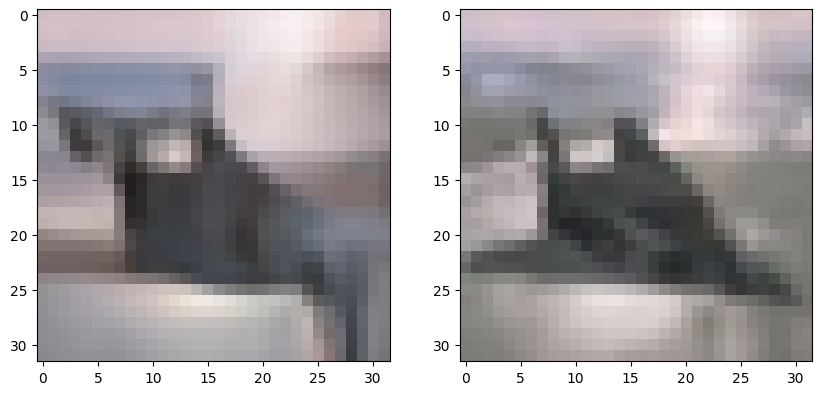

In [40]:
## Visualization of the image generated by DDIM diffuser
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(clear_image_scaled[-1].permute(1,2,0).cpu())
plt.subplot(1,2,2)
plt.imshow(test_images[255])
plt.show()